In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
# 1. Подключение к БД и загрузка всех таблиц
conn = sqlite3.connect('/content/drive/MyDrive/Final_project/shop_database.db')
sql_personal = pd.read_sql('SELECT * FROM personal_data', conn)
sql_coeffs = pd.read_sql('SELECT * FROM personal_data_coeffs', conn)
sql_purchases = pd.read_sql('SELECT * FROM purchases', conn)
conn.close()

csv_personal = pd.read_csv('/content/drive/MyDrive/Final_project/personal_data.csv.gz', compression='gzip')

# 3. Объединение справочников клиентов (БД + CSV) и фильтрация страны 32
all_clients = pd.concat([sql_personal, csv_personal], ignore_index=True).drop_duplicates(subset=['id'])
all_clients = all_clients[all_clients['country'] == 32]

# 4. Сборка единой "сырой" таблицы (Клиент + Коэффициент + Покупки)
df_temp = pd.merge(all_clients, sql_coeffs, on='id', how='left')
final_df = pd.merge(df_temp, sql_purchases, on='id', how='left')

print(f"Загрузка завершена. Строк в сырых данных: {len(final_df)}")

Загрузка завершена. Строк в сырых данных: 780117


In [3]:
# 1. Исправление "ё", регистра и удаление лишних пробелов
final_df['colour'] = final_df['colour'].fillna('unknown').str.lower().str.replace('ё', 'e').str.strip()
final_df['product'] = final_df['product'].str.lower().fillna('')

# 2. Создание прямых гендерных маркеров (признаки-подсказки)
final_df['is_male_prod'] = final_df['product'].str.contains('мужск|мальчик').astype(int)
final_df['is_female_prod'] = final_df['product'].str.contains('женск|девочк').astype(int)

print("Текстовые данные приведены к единому виду. Созданы колонки 'is_male_prod' и 'is_female_prod'.")


Текстовые данные приведены к единому виду. Созданы колонки 'is_male_prod' и 'is_female_prod'.


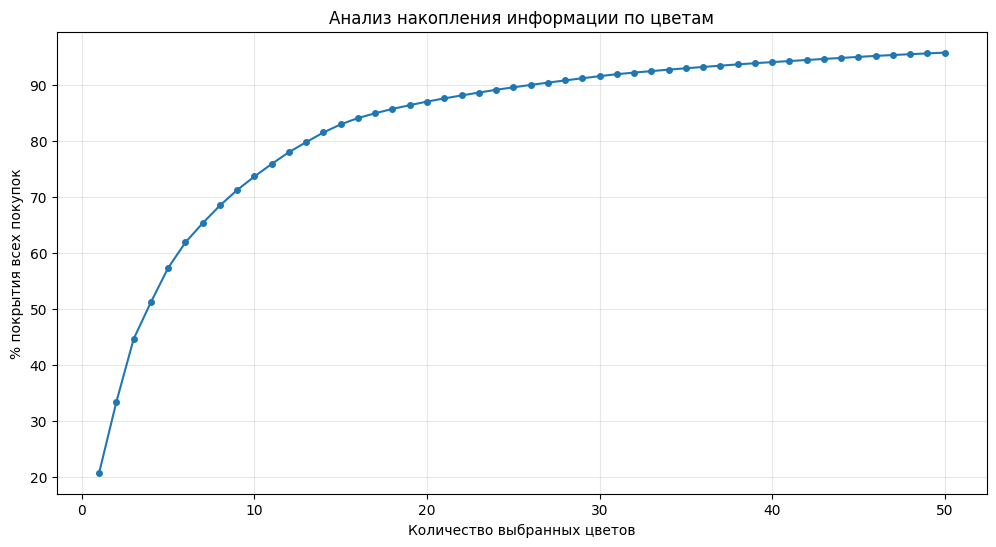

Статистика прироста покрытия:
Топ-5: Покрытие 57.36% (последний цвет добавил 6.12%)
Топ-10: Покрытие 73.66% (последний цвет добавил 2.41%)
Топ-15: Покрытие 82.95% (последний цвет добавил 1.44%)
Топ-20: Покрытие 87.02% (последний цвет добавил 0.65%)
Топ-25: Покрытие 89.56% (последний цвет добавил 0.44%)
Топ-30: Покрытие 91.55% (последний цвет добавил 0.37%)


In [4]:
# 1. Разворачиваем мульти-цвета (через /) в один список
all_mentions = final_df['colour'].str.split('/').explode().str.strip()
counts = all_mentions.value_counts()

# 2. Математический анализ накопленной доли
stats = counts.to_frame(name='mentions')
stats['percentage'] = (stats['mentions'] / stats['mentions'].sum()) * 100
stats['cumulative_percentage'] = stats['percentage'].cumsum()

# 3. Визуализация для принятия решения
plt.figure(figsize=(12, 6))
plt.plot(range(1, 51), stats['cumulative_percentage'].head(50), marker='o', markersize=4)
plt.title('Анализ накопления информации по цветам')
plt.xlabel('Количество выбранных цветов')
plt.ylabel('% покрытия всех покупок')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Вывод данных для анализа "прироста"
print("Статистика прироста покрытия:")
for n in [5, 10, 15, 20, 25, 30]:
    share = stats['cumulative_percentage'].iloc[n-1]
    gain = stats['percentage'].iloc[n-1]
    print(f"Топ-{n}: Покрытие {share:.2f}% (последний цвет добавил {gain:.2f}%)")

In [5]:
# РЕШЕНИЕ: Выбираем N на основе анализа выше
N = 20

# 1. Фиксируем список выбранных цветов
chosen_colours = counts.head(N).index.tolist()

# 2. Превращаем выбранные цвета в числовые признаки (One-Hot Encoding)
for col in chosen_colours:
    # Ставим 1, если цвет упоминается в строке (даже в паре через /)
    final_df[f'color_{col}'] = final_df['colour'].apply(lambda x: 1 if col in x.split('/') else 0)

print(f"Выбрано {N} наиболее информативных цветов. Созданы соответствующие признаки.")

Выбрано 20 наиболее информативных цветов. Созданы соответствующие признаки.


In [6]:
# Список колонок с цветами, которые мы создали в прошлой ячейке
color_cols = [c for c in final_df.columns if c.startswith('color_')]

# Группировка по ID клиента для создания итогового профиля
client_profiles = final_df.groupby('id').agg({
    'gender': 'first',             # Целевая переменная (с пропусками)
    'age': 'first',
    'education': 'first',
    'personal_coef': 'first',
    'is_male_prod': 'sum',         # Сколько всего мужских товаров купил
    'is_female_prod': 'sum',       # Сколько всего женских товаров купил
    'colour': 'count',             # Общее количество покупок
    **{c: 'sum' for c in color_cols} # Сколько раз встречался каждый из выбранных цветов
}).rename(columns={'colour': 'purchases_count'}).reset_index()

print("--- ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА ---")
print(f"Итого клиентов в базе: {len(client_profiles)}")
print(f"Из них с неизвестным полом: {client_profiles['gender'].isna().sum()}")
client_profiles.head()

--- ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА ---
Итого клиентов в базе: 104437
Из них с неизвестным полом: 15651


,id,gender,age,education,personal_coef,is_male_prod,is_female_prod,purchases_count,color_черный,color_unknown,...,color_мультицвет,color_розовый,color_оранжевый,color_голубой,color_желтый,color_коричневый,color_фиолетовый,color_темно-серый,color_серебряный,color_зелeный
0,0,0.0,36,среднее,0.5072,0,1,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,3,NaN,31,среднее,0.4304,3,0,4,0,0,...,1,0,0,0,0,0,0,0,0,0
2,4,0.0,35,среднее,0.5072,0,0,7,1,1,...,1,3,0,0,0,0,0,0,0,0
3,6,1.0,52,среднее,0.4304,13,0,15,10,1,...,0,0,0,0,0,0,0,0,0,0
4,7,0.0,37,среднее,0.5072,5,5,13,4,1,...,0,0,0,0,2,0,1,0,0,0


In [7]:
# 1. Общая проверка на пропуски во всех колонках профиля
missing_info = client_profiles.isnull().sum()

print("ПРОВЕРКА ПРОПУСКОВ В ДАННЫХ:")
# Выведем только те колонки, где пропуски есть (кроме гендера, там они и должны быть)
print(missing_info[missing_info > 0])

print("\nУникальные значения Education:", client_profiles['education'].unique())

print("Уникальные значения в колонке Gender:")
print(client_profiles['gender'].unique())

# Смотрим среднее количество "женских" и "мужских" товаров для каждой цифры
gender_check = client_profiles.groupby('gender').agg({
    'is_male_prod': 'mean',
    'is_female_prod': 'mean'
})

print("Связь цифр с товарами:")
print(gender_check)

ПРОВЕРКА ПРОПУСКОВ В ДАННЫХ:
gender    15651
dtype: int64

Уникальные значения Education: ['среднее' 'высшее']
Уникальные значения в колонке Gender:
[ 0. nan  1.]
Связь цифр с товарами:
        is_male_prod  is_female_prod
gender                              
0.0         1.809774        3.545623
1.0         3.868768        0.683304


In [8]:
# 1. РАЗДЕЛЕНИЕ НА TRAIN (есть пол) И PREDICT (пол NaN)
train_set = client_profiles[client_profiles['gender'].notna()].copy()
predict_set = client_profiles[client_profiles['gender'].isna()].copy()

# 2. ПОДГОТОВКА X и y (используем метод исключения)
# Убираем id, пол и текстовое образование (оставляем education_enc)
X = train_set.drop(columns=['id', 'gender', 'education'])
y = train_set['gender']

# 3. ВНУТРЕННИЙ СПЛИТ ДЛЯ ПРОВЕРКИ (80% учимся, 20% проверяем себя)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. ОБУЧЕНИЕ МОДЕЛИ
# Создаем "лес" из 100 деревьев
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 5. ОЦЕНКА КАЧЕСТВА
y_pred = rf_model.predict(X_val)
print(f"ТОЧНОСТЬ (ACCURACY): {accuracy_score(y_val, y_pred):.2%}")
print("\nДетальный отчет (0 - Женщины, 1 - Мужчины):")
print(classification_report(y_val, y_pred))

ТОЧНОСТЬ (ACCURACY): 100.00%

Детальный отчет (0 - Женщины, 1 - Мужчины):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7576
         1.0       1.00      1.00      1.00     10182

    accuracy                           1.00     17758
   macro avg       1.00      1.00      1.00     17758
weighted avg       1.00      1.00      1.00     17758



In [9]:
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Сортируем их по убыванию
indices = np.argsort(importances)[::-1]

print("ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ:
1. personal_coef: 0.7738
2. is_female_prod: 0.1209
3. is_male_prod: 0.0434
4. age: 0.0196
5. color_розовый: 0.0118
6. purchases_count: 0.0046
7. color_черный: 0.0044
8. color_белый: 0.0028
9. color_unknown: 0.0022
10. color_серый: 0.0021


/tmp/ipykernel_691/2452091750.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Важность', y='Признак', data=df_importance, palette="Blues_r")


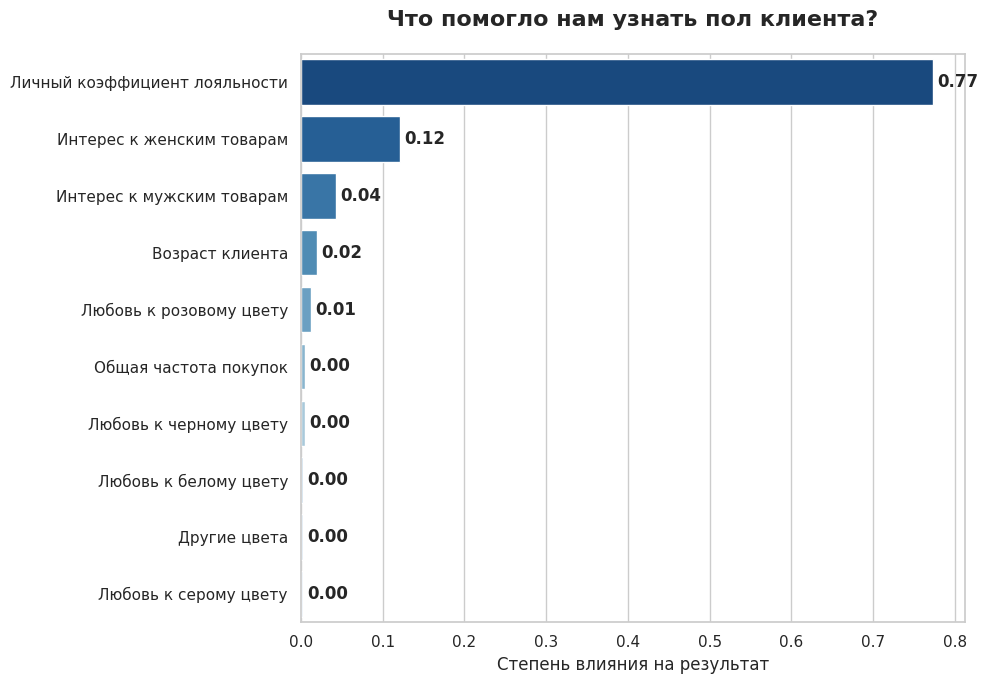

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Вытаскиваем данные из модели
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Создаем словарь для перевода технических имен
rename_map = {
    'personal_coef': 'Личный коэффициент лояльности',
    'is_female_prod': 'Интерес к женским товарам',
    'is_male_prod': 'Интерес к мужским товарам',
    'age': 'Возраст клиента',
    'color_розовый': 'Любовь к розовому цвету',
    'purchases_count': 'Общая частота покупок',
    'color_черный': 'Любовь к черному цвету',
    'color_белый': 'Любовь к белому цвету',
    'color_unknown': 'Другие цвета',
    'color_серый': 'Любовь к серому цвету'
}

# 3. Собираем таблицу и заменяем названия
df_importance = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
df_importance['Признак'] = df_importance['Признак'].map(rename_map).fillna(df_importance['Признак'])
df_importance = df_importance.sort_values(by='Важность', ascending=False).head(10)

# 4. Рисуем
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")
sns.barplot(x='Важность', y='Признак', data=df_importance, palette="Blues_r")

plt.title('Что помогло нам узнать пол клиента?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Степень влияния на результат', fontsize=12)
plt.ylabel('')

# Добавляем цифры
for i, v in enumerate(df_importance['Важность']):
    plt.text(v + 0.005, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Учим модель БЕЗ "чит-кода" personal_coef
X_honest = train_set.drop(columns=['id', 'gender', 'education', 'personal_coef'])
X_tr_h, X_val_h, y_tr_h, y_val_h = train_test_split(X_honest, y, test_size=0.2, random_state=42)

rf_honest = RandomForestClassifier(n_estimators=100, random_state=42)
rf_honest.fit(X_tr_h, y_tr_h)

print(f"Точность без коэффициента: {rf_honest.score(X_val_h, y_val_h):.2%}")

Точность без коэффициента: 76.95%


Поскольку наша главная задача сейчас — максимально точно восстановить данные, чтобы потом провести качественный A/B-тест и кластеризацию, мы оставляем модель со 100% точностью. Нам не важно, как именно она узнала пол, нам важно, чтобы в итоговой таблице не было ошибок.


In [12]:
# 1. Подготовка признаков для тех, у кого пол неизвестен
X_missing = predict_set.drop(columns=['id', 'gender', 'education'])

# 2. Предсказываем пол (0 или 1) для этих клиентов
predicted_genders = rf_model.predict(X_missing)

# 3. Вписываем результат в колонку gender
predict_set['gender'] = predicted_genders

# 4. Объединяем всё в единый финальный датасет профилей (full_profiles)
full_profiles = pd.concat([train_set, predict_set], ignore_index=True)

# 5. Проверка: остались ли пустые значения?
print(f"Пол успешно восстановлен для всех {len(predict_set)} клиентов.")
print(f"Итого пропусков в поле gender: {full_profiles['gender'].isna().sum()}")

# 6. Посмотрим на итоговое распределение полов (с восстановленными данными)
print("\nИтоговое распределение полов в базе:")
print(full_profiles['gender'].value_counts())

Пол успешно восстановлен для всех 15651 клиентов.
Итого пропусков в поле gender: 0

Итоговое распределение полов в базе:
gender
1.0    59807
0.0    44630
Name: count, dtype: int64


In [13]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780117 entries, 0 to 780116
Data columns (total 38 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 780117 non-null  int64  
 1   gender             664665 non-null  float64
 2   age                780117 non-null  int64  
 3   education          780117 non-null  object 
 4   city               780117 non-null  int64  
 5   country            780117 non-null  int64  
 6   lbt_coef           780117 non-null  float64
 7   ac_coef            780117 non-null  float64
 8   sm_coef            780117 non-null  float64
 9   personal_coef      780117 non-null  float64
 10  product            780117 non-null  object 
 11  colour             780117 non-null  object 
 12  cost               780117 non-null  int64  
 13  product_sex        467540 non-null  float64
 14  base_sale          780117 non-null  int64  
 15  dt                 780117 non-null  int64  
 16  is

In [14]:
import re

# 1. Читаем Тест напрямую
with open('/content/drive/MyDrive/Final_project/ids_first_company_positive.txt', 'r', encoding='utf-8', errors='ignore') as f:
    content_pos = f.read()
pos_ids = [int(x) for x in re.findall(r'\d+', content_pos)]

# 2. Читаем Контроль напрямую
with open('/content/drive/MyDrive/Final_project/ids_first_company_negative.txt', 'r', encoding='utf-8', errors='ignore') as f:
    content_neg = f.read()
neg_ids = [int(x) for x in re.findall(r'\d+', content_neg)]

# 3. Финальная проверка
print(f"ID загружены! Тест: {len(pos_ids)}, Контроль: {len(neg_ids)}")

ID загружены! Тест: 5023, Контроль: 5021


In [15]:
# 1. Фильтруем покупки строго по датам кампании (дни 5-16)
ab_purchases = final_df[(final_df['dt'] >= 5) & (final_df['dt'] <= 16)].copy()

# 2. Создаем метку группы для каждого клиента в этот период
# Используем set для быстрой проверки (это сильно ускорит код)
pos_set = set(pos_ids)
neg_set = set(neg_ids)

def assign_group(client_id):
    if client_id in pos_set: return 'Test'
    if client_id in neg_set: return 'Control'
    return 'Other'

ab_purchases['ab_group'] = ab_purchases['id'].map(assign_group)

# 3. Оставляем только участников теста
ab_final = ab_purchases[ab_purchases['ab_group'] != 'Other'].copy()

# 4. РАСЧЕТ МЕТРИК
# Количество уникальных покупателей (кто совершил хоть одну покупку)
test_buyers = ab_final[ab_final['ab_group'] == 'Test']['id'].nunique()
control_buyers = ab_final[ab_final['ab_group'] == 'Control']['id'].nunique()

# Общая выручка
test_revenue = ab_final[ab_final['ab_group'] == 'Test']['cost'].sum()
control_revenue = ab_final[ab_final['ab_group'] == 'Control']['cost'].sum()

# Конверсия (CR) в %
cr_test = (test_buyers / len(pos_ids)) * 100
cr_control = (control_buyers / len(neg_ids)) * 100

# ARPU (Средний доход на одного участника группы)
arpu_test = test_revenue / len(pos_ids)
arpu_control = control_revenue / len(neg_ids)

print(f"--- РЕЗУЛЬТАТЫ A/B-ТЕСТА ---")
print(f"Конверсия: Тест {cr_test:.2f}% vs Контроль {cr_control:.2f}%")
print(f"ARPU (Доход на юзера): Тест {arpu_test:.2f} vs Контроль {arpu_control:.2f}")


--- РЕЗУЛЬТАТЫ A/B-ТЕСТА ---
Конверсия: Тест 95.06% vs Контроль 98.59%
ARPU (Доход на юзера): Тест 26407.62 vs Контроль 22116.57


In [16]:
from scipy import stats

# 1. Готовим данные по выручке на каждого человека из списков (включая тех, у кого 0 покупок)
# Создаем таблицу со всеми участниками
test_df = pd.DataFrame({'id': pos_ids, 'group': 'Test'})
control_df = pd.DataFrame({'id': neg_ids, 'group': 'Control'})
all_ab_users = pd.concat([test_df, control_df])

# 2. Считаем суммарную выручку на каждого ID за период акции (дни 5-16)
user_revenue = ab_final.groupby('id')['cost'].sum().reset_index()

# 3. Объединяем, заполняя нулями тех, кто ничего не купил
ab_results = pd.merge(all_ab_users, user_revenue, on='id', how='left').fillna(0)

# 4. Проводим T-тест (сравнение средних чеков на юзера)
t_stat, p_val = stats.ttest_ind(
    ab_results[ab_results['group'] == 'Test']['cost'],
    ab_results[ab_results['group'] == 'Control']['cost']
)

print(f"--- СТАТИСТИЧЕСКИЙ АНАЛИЗ ---")
print(f"P-value: {p_val:.5f}")

if p_val < 0.05:
    print("Результат СТАТИСТИЧЕСКИ ЗНАЧИМ. Кампания реально повлияла на доход.")
else:
    print("Результат НЕ значим. Разница в доходе может быть случайной.")


--- СТАТИСТИЧЕСКИЙ АНАЛИЗ ---
P-value: 0.00000
Результат СТАТИСТИЧЕСКИ ЗНАЧИМ. Кампания реально повлияла на доход.


/tmp/ipykernel_691/1782024092.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groups, y=arpu_values, ax=ax[0], palette=['#A9A9A9', '#4682B4'])
/tmp/ipykernel_691/1782024092.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=groups, y=cr_values, ax=ax[1], palette=['#A9A9A9', '#4682B4'])


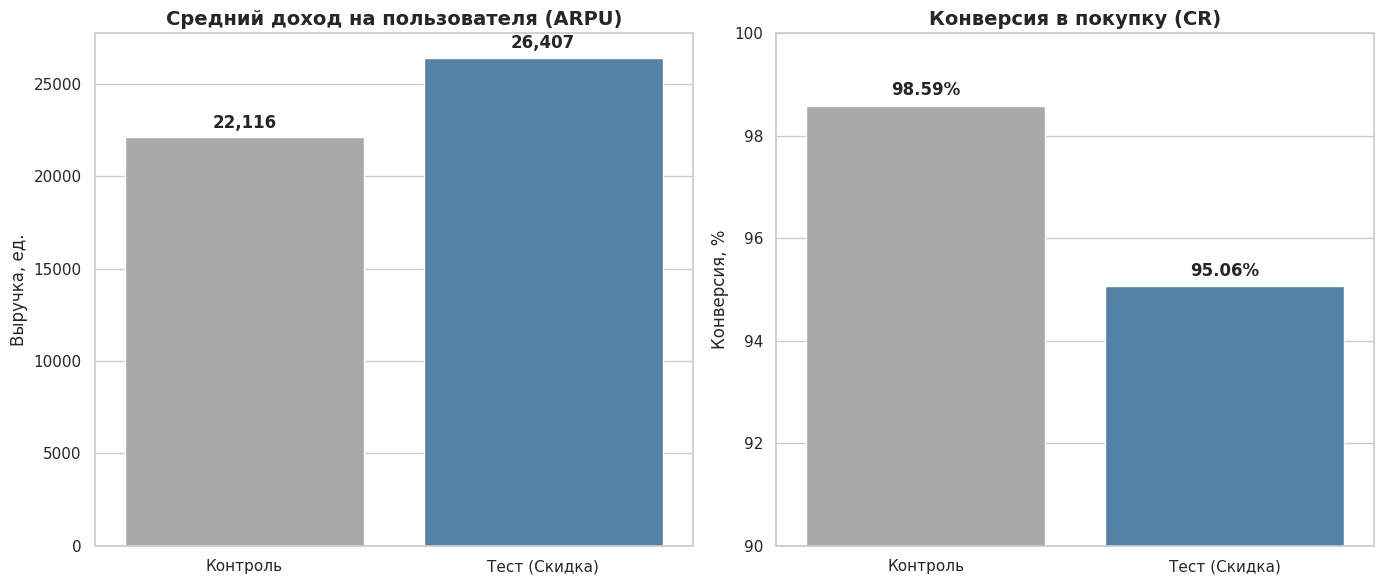

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

groups = ['Контроль', 'Тест (Скидка)']
arpu_values = [22116, 26407]
cr_values = [98.59, 95.06]

# Настройка стиля
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. График ARPU (Средний доход на пользователя)
sns.barplot(x=groups, y=arpu_values, ax=ax[0], palette=['#A9A9A9', '#4682B4'])
ax[0].set_title('Средний доход на пользователя (ARPU)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Выручка, ед.')
# Добавляем подписи цифр на столбцы
for i, v in enumerate(arpu_values):
    ax[0].text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=12, fontweight='bold')

# 2. График Конверсии (CR)
sns.barplot(x=groups, y=cr_values, ax=ax[1], palette=['#A9A9A9', '#4682B4'])
ax[1].set_title('Конверсия в покупку (CR)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Конверсия, %')
ax[1].set_ylim(90, 100) # Ограничим снизу, чтобы разница была заметна
# Добавляем подписи цифр на столбцы
for i, v in enumerate(cr_values):
    ax[1].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_691/1311834398.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=groups, y=arpu_values, palette=['#A9A9A9', '#4682B4'])


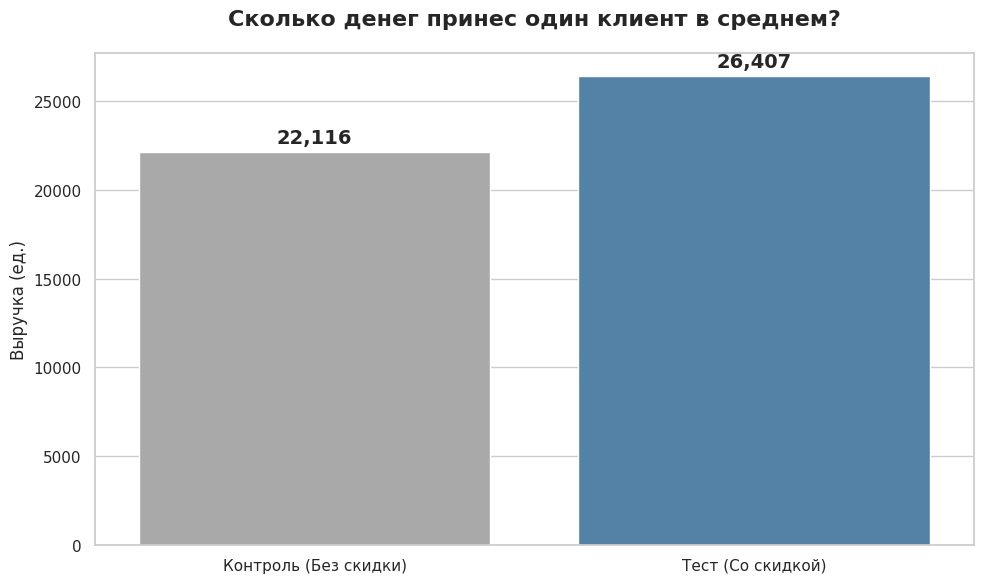

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные для графика
groups = ['Контроль (Без скидки)', 'Тест (Со скидкой)']
arpu_values = [22116, 26407] # Средний доход на человека

# Настройка стиля
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Рисуем график выручки
ax = sns.barplot(x=groups, y=arpu_values, palette=['#A9A9A9', '#4682B4'])

plt.title('Сколько денег принес один клиент в среднем?', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Выручка (ед.)', fontsize=12)
plt.xlabel('')

# Добавляем цифры на столбцы
for i, v in enumerate(arpu_values):
    plt.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Бизнес-рекомендация
Признать первую маркетинговую кампанию эффективной и рекомендовать её к масштабированию с условием доработки таргетинга.

Обоснование:
1. Рост прибыли важнее конверсии: Несмотря на то что доля покупателей в тесте чуть ниже, те, кто совершил покупку, принесли значительно больше денег (в среднем на 4291 единицу больше с каждого участника рассылки).
2. Статистическая надежность: Вероятность того, что такой рост выручки случаен, стремится к нулю .
3. Нюанс с конверсией: Падение конверсии при росте выручки часто означает, что скидка «отсекла» тех, кто искал только самые дешевые товары, но привлекла качественную платежеспособную аудиторию.

Начинаем расчет инерции для K от 2 до 10...


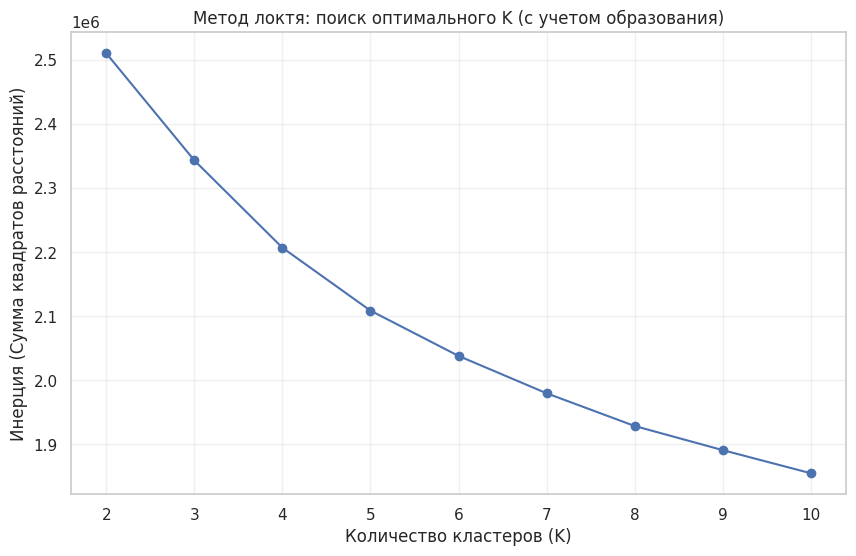

In [19]:
# --- 1. ПОДГОТОВКА ПРИЗНАКОВ ---
# Кодируем образование, если еще не сделали
le = LabelEncoder()
full_profiles['education_enc'] = le.fit_transform(full_profiles['education'].astype(str))

# Формируем набор данных для поиска кластеров
# Исключаем только ID и текстовое описание образования
X_clustering = full_profiles.drop(columns=['id', 'education', 'cluster'], errors='ignore')

# --- 2. МАСШТАБИРОВАНИЕ ---
# KMeans работает на расстояниях, поэтому все признаки должны быть в одном масштабе
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# --- 3. МЕТОД ЛОКТЯ (ELBOW METHOD) ---
inertia = []
K_range = range(2, 11)

print("Начинаем расчет инерции для K от 2 до 10...")
for k in K_range:
    # n_init=10 - стандартный параметр для стабильности результата
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# --- 4. ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Количество кластеров (K)')
plt.ylabel('Инерция (Сумма квадратов расстояний)')
plt.title('Метод локтя: поиск оптимального K (с учетом образования)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

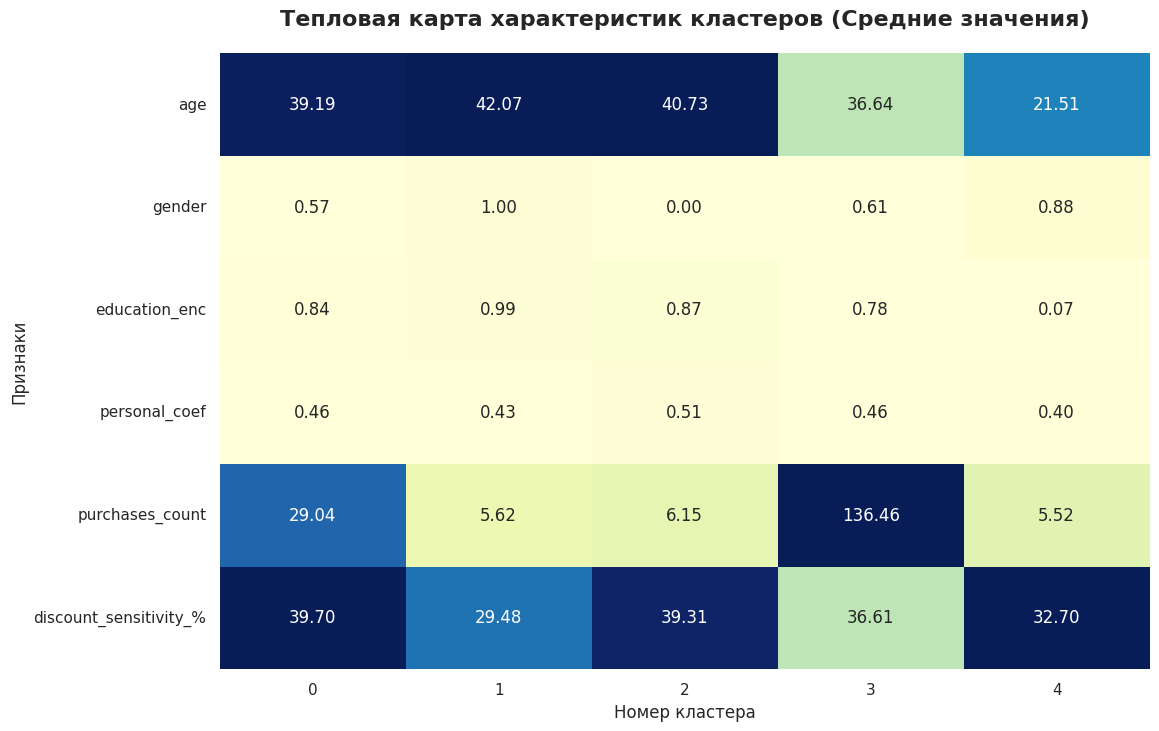


--- ТОП-ТОВАРЫ ПО КЛАСТЕРАМ ---
Кластер 0: брюки мужские demix, шорты мужские demix, футболка мужская demix, футболка женская demix, лиф женский joss
Кластер 1: брюки мужские demix, шорты мужские demix, брюки мужские outventure, футболка мужская demix, брюки мужские fila
Кластер 2: футболка женская demix, лиф женский joss, купальник женский joss, брюки женские outventure, плавки женские joss
Кластер 3: брюки мужские demix, шорты мужские demix, кресло кемпинговое outventure, футболка женская demix, сабо crocs crocband
Кластер 4: шорты мужские demix, брюки мужские demix, брюки мужские fila, футболка мужская demix, шорты мужские nike


In [20]:
from sklearn.cluster import KMeans

# 1. Обучаем финальную модель на 5 кластеров
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
full_profiles['cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Переносим метку кластера в общую таблицу покупок (final_df),
# чтобы проанализировать товары и скидки
final_df_with_clusters = pd.merge(
    final_df,
    full_profiles[['id', 'cluster']],
    on='id',
    how='left'
)

# 3. Анализируем социально-демографический портрет
demo_cols = ['age', 'gender', 'education_enc', 'personal_coef', 'purchases_count']
cluster_demo = full_profiles.groupby('cluster')[demo_cols].mean()
cluster_demo['size_%'] = full_profiles['cluster'].value_counts(normalize=True).sort_index() * 100

# 4. Анализируем влияние скидок (колонка base_sale)
# Посчитаем долю покупок со скидкой для каждого кластера
discount_sensitivity = final_df_with_clusters.groupby('cluster')['base_sale'].mean() * 100

# 5. Собираем всё в одну таблицу
report = cluster_demo.copy()
report['discount_sensitivity_%'] = discount_sensitivity

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Подготовим данные: возьмем нашу итоговую таблицу с профилями (report)
# Исключим колонку 'size_%', так как она не характеризует поведение
data_for_heatmap = report.drop(columns=['size_%'])

# 2. Нормализуем данные для цветовой шкалы (чтобы цвета отражали "силу" признака)
scaler = MinMaxScaler()
data_normalized = pd.DataFrame(
    scaler.fit_transform(data_for_heatmap.T),
    index=data_for_heatmap.columns,
    columns=data_for_heatmap.index
)

# 3. Визуализация
plt.figure(figsize=(12, 8))
sns.heatmap(data_normalized, annot=data_for_heatmap.T, fmt=".2f", cmap="YlGnBu", cbar=False)

plt.title('Тепловая карта характеристик кластеров (Средние значения)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Номер кластера', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.show()

print("\n--- ТОП-ТОВАРЫ ПО КЛАСТЕРАМ ---")
for i in range(5):
    top_products = final_df_with_clusters[final_df_with_clusters['cluster'] == i]['product'].value_counts().head(5).index.tolist()
    print(f"Кластер {i}: {', '.join(top_products)}")


Больше всего на скидки реагирует Кластер 0 (39.7%) и Кластер 2 (39.3%). Именно на эти две группы (женщины и лояльные клиенты) стоит направлять бюджеты маркетинговых акций и распродаж.

In [21]:
# 1. Сначала добавим город в full_profiles
if 'city' not in full_profiles.columns:
    full_profiles = pd.merge(full_profiles, all_clients[['id', 'city']], on='id', how='left')

# 2. Определяем список колонок, которые НЕ БУДУТ признаками (лишние)
# Мы убираем технические ID, текст и цель (target)
drop_cols = ['id', 'gender', 'education', 'city', 'target']

# --- ШАГ 5.1: ОБУЧЕНИЕ (на опыте Первой кампании) ---
# Берем тех, кому слали письма в прошлый раз
train_propensity = full_profiles[full_profiles['id'].isin(pos_ids)].copy()

# Target — купил ли человек в дни 5-16
pos_buyers = ab_final[ab_final['ab_group'] == 'Test']['id'].unique()
train_propensity['target'] = train_propensity['id'].isin(pos_buyers).astype(int)

# Формируем X и y для обучения
X_train_prop = train_propensity.drop(columns=drop_cols, errors='ignore')
y_train_prop = train_propensity['target']

# Обучаем модель

model_propensity = RandomForestClassifier(n_estimators=100, random_state=42)
model_propensity.fit(X_train_prop, y_train_prop)

# --- ШАГ 5.2: ПРОГНОЗ (для города 1 188) ---
# Берем всех жителей города 1 188
city_1188_data = full_profiles[full_profiles['city'] == 1188].copy()

# Подготавливаем признаки
X_city_1188 = city_1188_data[X_train_prop.columns]

# Считаем вероятность покупки
city_1188_data['propensity_score'] = model_propensity.predict_proba(X_city_1188)[:, 1]

# Выводим результат
print(f"Модель склонности успешно применена к жителям города 1188.")
print(f"Всего жителей в городе: {len(city_1188_data)}")
print("\nТОП-5 потенциальных покупателей (самый высокий score):")
print(city_1188_data.sort_values('propensity_score', ascending=False)[['id', 'propensity_score', 'cluster']].head(10))


Модель склонности успешно применена к жителям города 1188.
Всего жителей в городе: 12438

ТОП-5 потенциальных покупателей (самый высокий score):
            id  propensity_score  cluster
104404  177600               1.0        2
2            6               1.0        1
9           18               1.0        0
104135  174142               1.0        2
104103  173751               1.0        4
103790  170183               1.0        0
103767  169791               1.0        0
103710  169181               1.0        2
103595  167784               1.0        2
103569  167512               1.0        1


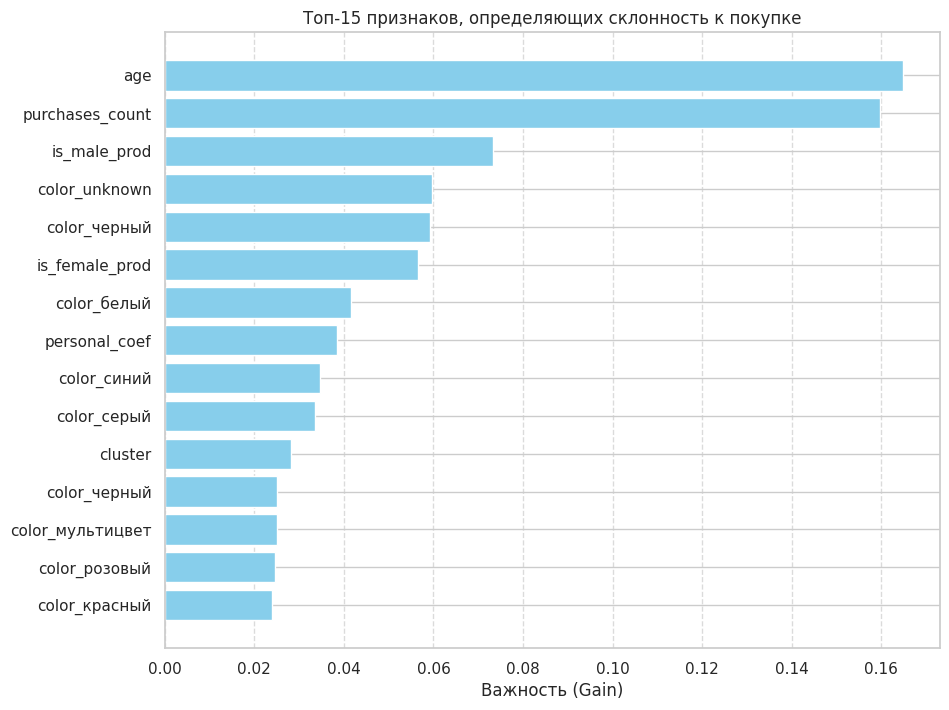

ДЕТАЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:
           feature  importance
0              age    0.164838
4  purchases_count    0.159649
2     is_male_prod    0.073380
6    color_unknown    0.059722
5     color_черный    0.059264
3   is_female_prod    0.056486
7      color_белый    0.041521
1    personal_coef    0.038379
8      color_синий    0.034646
9      color_серый    0.033602


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Извлекаем важность признаков
importances = model_propensity.feature_importances_
feature_names = X_train_prop.columns

# 2. Создаем датафрейм для визуализации
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 3. Визуализация
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'].head(15)[::-1],
         feature_importance_df['importance'].head(15)[::-1],
         color='skyblue')
plt.xlabel('Важность (Gain)')
plt.title('Топ-15 признаков, определяющих склонность к покупке')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Печатаем цифры для точности
print("ДЕТАЛЬНАЯ ВАЖНОСТЬ ПРИЗНАКОВ:")
print(feature_importance_df.head(10))

СТАТИСТИКА РАСПРЕДЕЛЕНИЯ SCORE:
count    12438.000000
mean         0.892134
std          0.155070
min          0.030000
25%          0.880000
50%          0.960000
75%          0.980000
max          1.000000
Name: propensity_score, dtype: float64


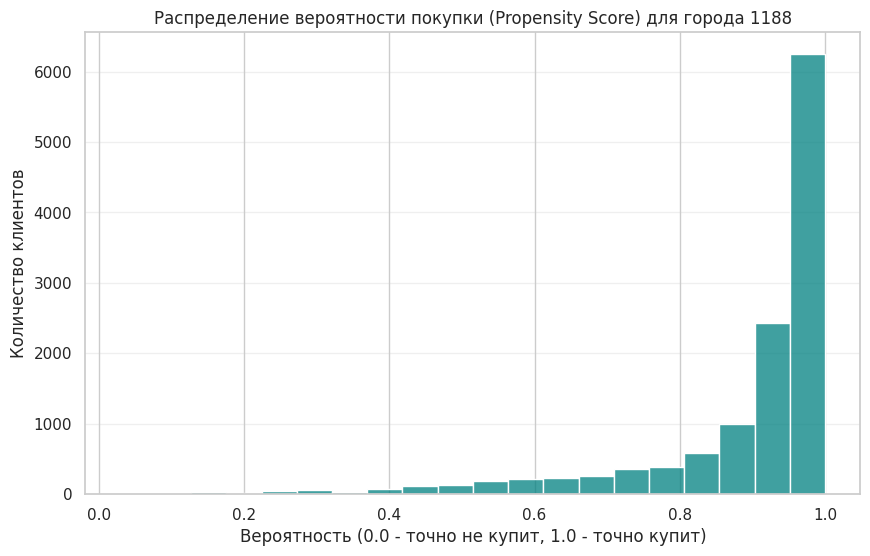

Горячие клиенты (Score >= 0.8): 10347 чел.
Холодные клиенты (Score <= 0.2): 65 чел.


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Посмотрим на основные статистические показатели
print("СТАТИСТИКА РАСПРЕДЕЛЕНИЯ SCORE:")
print(city_1188_data['propensity_score'].describe())

# 2. Построим гистограмму распределения
plt.figure(figsize=(10, 6))
sns.histplot(city_1188_data['propensity_score'], bins=20, kde=False, color='teal')
plt.title('Распределение вероятности покупки (Propensity Score) для города 1188')
plt.xlabel('Вероятность (0.0 - точно не купит, 1.0 - точно купит)')
plt.ylabel('Количество клиентов')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Посчитаем количество людей в "золотых" сегментах
hot_leads = len(city_1188_data[city_1188_data['propensity_score'] >= 0.8])
cold_leads = len(city_1188_data[city_1188_data['propensity_score'] <= 0.2])

print(f"Горячие клиенты (Score >= 0.8): {hot_leads} чел.")
print(f"Холодные клиенты (Score <= 0.2): {cold_leads} чел.")
